# Cloud-fraction P(detect) curve (reviewer response)

Standalone figure for the App. E discussion of `cloud_fraction_crb`'s
modest permutation importance. Three panels:

- (a) Distribution of `cloud_fraction_crb` after qa>0.75 filter (truncation)
- (b) U.S. P(detect) vs `cloud_fraction_crb` quantile bin
- (c) Global P(detect) vs `cloud_fraction_crb` quantile bin

Same dataset filters as the main analysis (171 plants for U.S.,
interference-filtered for global).

In [8]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

sys.path.insert(0, '/net/fs06/d3/rzhuang/TROPOMI/code')
from shared.interference import (identify_interference_us_by_year,
                                 identify_interference_world)

plt.rcdefaults()
plt.rcParams.update({
    'figure.dpi': 300, 'savefig.dpi': 300,
    'font.size': 11, 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#2E3440', 'text.color': '#2E3440',
})

# Register Nimbus Roman
nimbus_path = None
for _p in fm.findSystemFonts():
    _pl = _p.lower()
    if ('nimbusroman' in _pl or 'nimbus_roman' in _pl) \
            and 'bold' not in _pl and 'italic' not in _pl and 'oblique' not in _pl:
        nimbus_path = _p; break
if nimbus_path:
    fm.fontManager.addfont(nimbus_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=nimbus_path).get_name()
    print('Registered:', plt.rcParams['font.family'])

colors = {'us': '#FF6B6B', 'global': '#4ECDC4', 'text': '#2E3440'}

# Paths
US_CSV    = '/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv'
WORLD_CSV = '/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/updated_tropomi_emissions_full_variables_with_fuel_100mlabel.csv'
US_FAC    = '/net/fs06/d3/rzhuang/TROPOMI/data/us/facility_emissions_by_plant_comprehensive.csv'
US_ANN    = '/net/fs06/d3/rzhuang/TROPOMI/data/us/annual-emissions-facility-aggregation-2019-2024.csv'
WORLD_PL  = '/net/fs06/d3/rzhuang/TROPOMI/data/world/power_plant_location/power_plants_with_combined_nearby_stats.csv'
CITY_CSV  = '/net/fs06/d3/rzhuang/TROPOMI/data/world/worldcities.csv'
OUT_DIR   = '/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures'
os.makedirs(OUT_DIR, exist_ok=True)

FEAT = 'cloud_fraction_crb'
N_BINS = 10

Registered: ['Nimbus Roman']


In [9]:
# ─── Load + apply paper filters ──────────────────────────────────────
print('Loading U.S. snapshots ...')
us = pd.read_csv(US_CSV).dropna()
us_pl = pd.read_csv(US_FAC).sort_values('NOx_Rank')
us_an = pd.read_csv(US_ANN)
city  = pd.read_csv(CITY_CSV)

US_YEARS = [2019, 2020, 2021, 2022, 2023, 2024]
top500   = us_pl.head(500)['Facility_ID'].tolist()
emis_top = us_an[us_an['Facility ID'].isin(top500)]
present  = emis_top[emis_top['Year'].isin(US_YEARS)].groupby('Facility ID')['Year'].nunique()
complete_6y = set(present[present == len(US_YEARS)].index)
interf_us = identify_interference_us_by_year(
    us_pl[us_pl['Facility_ID'].isin(complete_6y)],
    emis_top[emis_top['Facility ID'].isin(complete_6y)],
    city, plant_subset_ids=list(complete_6y))
ever = set().union(*[set(v) for v in interf_us.values()])
us_kept = complete_6y - ever
df_us = us[us['location'].isin(us_kept)].copy()
print(f'U.S.: {len(df_us):,} obs across {len(us_kept)} plants (171 recipe)')

print('\nLoading global snapshots ...')
wl = pd.read_csv(WORLD_CSV).dropna(subset=['plume_label','location',FEAT])
wl_pl = pd.read_csv(WORLD_PL)
gl_ids = wl['location'].astype(str).str.strip().unique().tolist()
interf_w = identify_interference_world(wl_pl, city, plant_subset_ids=gl_ids)
df_gl = wl[~wl['location'].astype(str).str.strip().isin({str(x).strip() for x in interf_w})].copy()
print(f'Global: {len(df_gl):,} obs across {df_gl["location"].nunique()} plants')

Loading U.S. snapshots ...
Identifying plants in interference zones by year...
Year 2019: 283 interfered / 460 plants
Year 2020: 283 interfered / 460 plants
Year 2021: 283 interfered / 460 plants
Year 2022: 283 interfered / 460 plants
Year 2023: 283 interfered / 460 plants
Year 2024: 283 interfered / 460 plants
U.S.: 189,713 obs across 171 plants (171 recipe)

Loading global snapshots ...
Identifying plants in interference zones (global)...


Checking interference: 100%|██████████| 6000/6000 [00:03<00:00, 1902.04it/s]


Found 4935 interfered / 6000 plants
Global: 161,118 obs across 1065 plants


In [10]:
# ─── P(detect) by cloud_fraction_crb quantile bin ────────────────────
def pod_curve(df, feat=FEAT, target='plume_label', n=N_BINS, clip=(0.01, 0.95)):
    """Quantile-binned POD vs feature. Bin centre is the *median observed
    value* in the bin (not the interval midpoint), so the plotted point
    sits where the data actually lives even when the bin spans a wide
    range (e.g. cf=1.0 outliers in the top quantile)."""
    s = pd.to_numeric(df[feat], errors='coerce')
    y = pd.to_numeric(df[target], errors='coerce').fillna(0).astype(int)
    m = s.notna()
    s, y = s[m], y[m]
    if clip:
        lo, hi = s.quantile(clip[0]), s.quantile(clip[1])
        m2 = (s >= lo) & (s <= hi)
        s, y = s[m2], y[m2]
    bins = pd.qcut(s, q=n, duplicates='drop')
    g_y = y.groupby(bins, observed=False)
    g_s = s.groupby(bins, observed=False)
    total, pos = g_y.count(), g_y.sum()
    pod   = pos / total.replace(0, np.nan)
    se    = np.sqrt(pod * (1 - pod) / total.replace(0, np.nan))
    centers = g_s.median()             # ← median of actual values, not iv.mid
    return pd.DataFrame({'center': centers.values, 'pod': pod.values,
                          'se': se.values, 'n': total.values})

p_us = pod_curve(df_us)
p_gl = pod_curve(df_gl)
print('U.S. POD curve:')
print(p_us.to_string(index=False))
print('\nGlobal POD curve:')
print(p_gl.to_string(index=False))


U.S. POD curve:
  center      pod       se     n
0.009204 0.409466 0.003682 17833
0.024287 0.360511 0.003596 17833
0.039508 0.347446 0.003566 17833
0.054508 0.343016 0.003555 17833
0.070680 0.339819 0.003547 17833
0.090018 0.322734 0.003501 17832
0.113678 0.308866 0.003460 17833
0.144576 0.302136 0.003439 17833
0.188397 0.287557 0.003389 17833
0.266219 0.293220 0.003409 17833

Global POD curve:
  center      pod       se     n
0.010592 0.454275 0.004046 15145
0.027968 0.418620 0.004009 15145
0.044970 0.411885 0.003999 15145
0.061745 0.395708 0.003974 15145
0.080118 0.393133 0.003969 15145
0.101012 0.380059 0.003944 15145
0.125104 0.376164 0.003936 15145
0.154548 0.377220 0.003938 15145
0.194041 0.374447 0.003933 15145
0.260398 0.350611 0.003877 15145


Saved: /net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/cloud_fraction_pod.pdf
Saved: /net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/cloud_fraction_pod.png


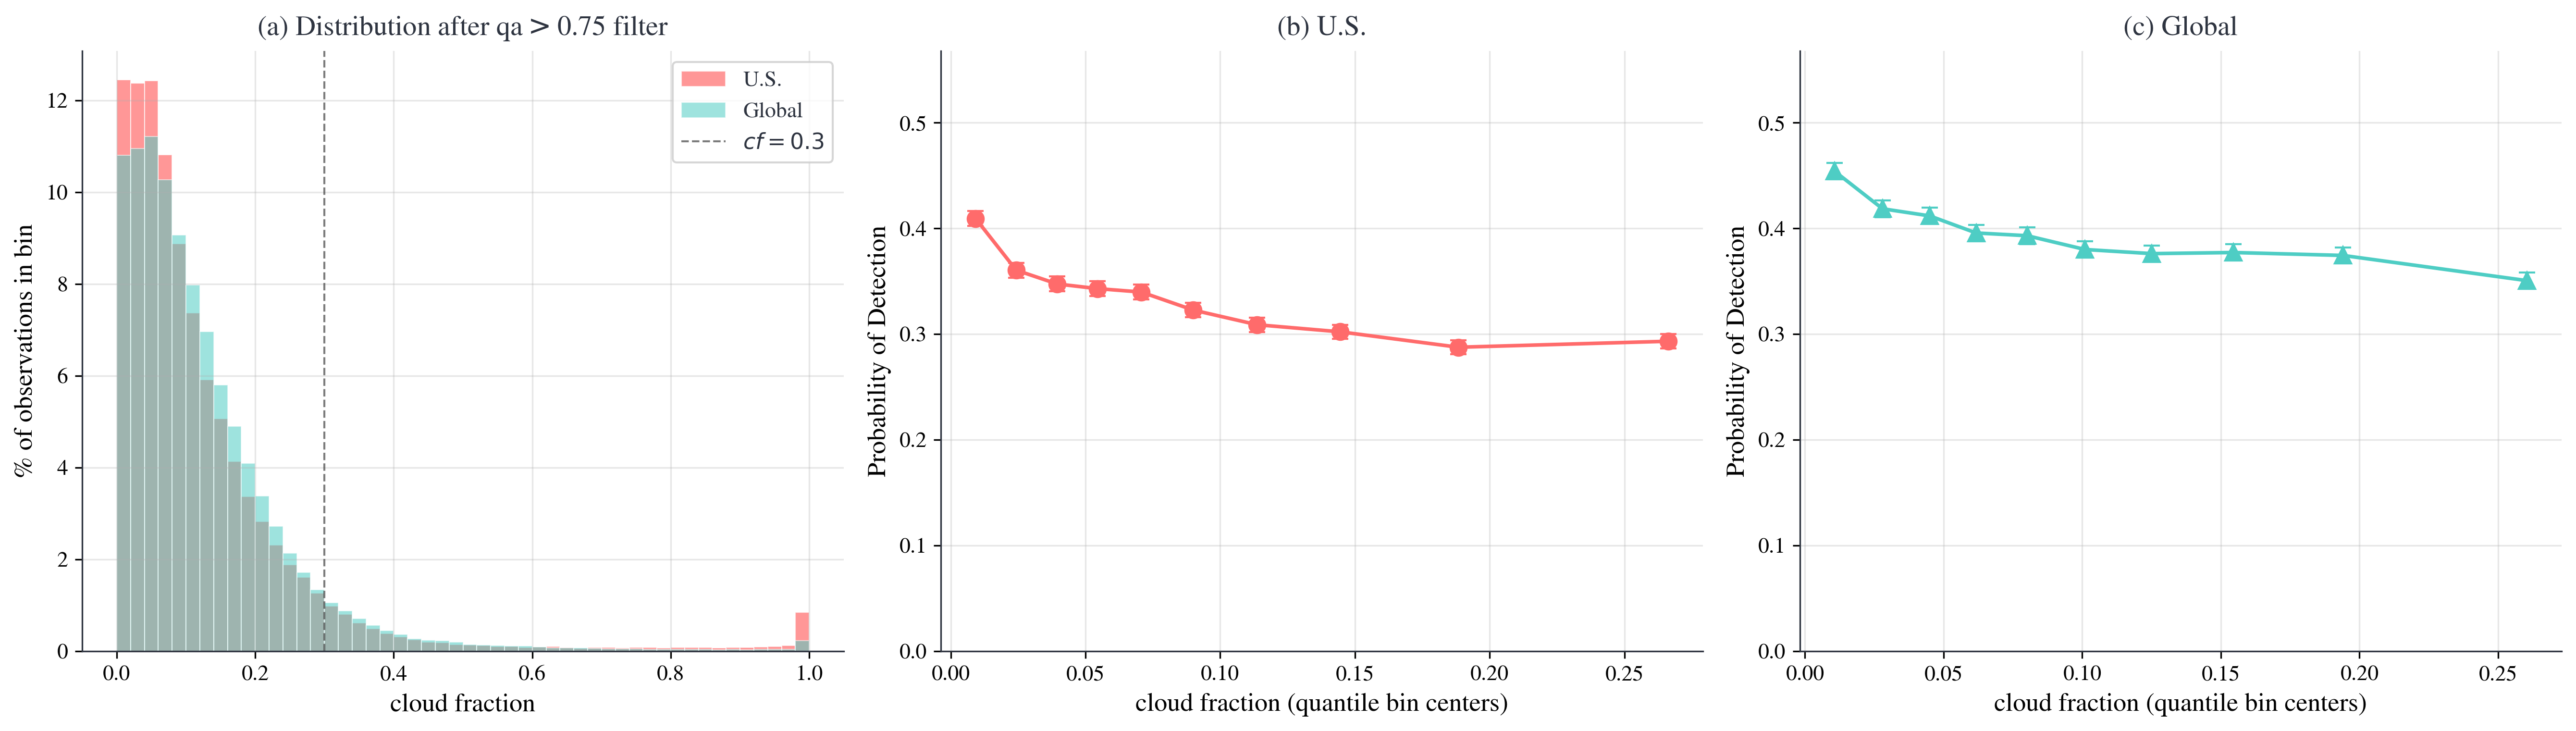

In [13]:
# ─── 3-panel figure: (a) distribution, (b) U.S. POD, (c) Global POD ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), facecolor='white')

# Panel a: % of observations per bin (rather than density), so the y-axis
# directly reads as "% of obs in bin". Two histograms are still comparable
# because each is normalised to its own dataset size.
ax = axes[0]
us_w = 100.0 / len(df_us) * np.ones(len(df_us))
gl_w = 100.0 / len(df_gl) * np.ones(len(df_gl))
ax.hist(df_us[FEAT], bins=50, range=(0, 1), weights=us_w,
        alpha=0.7, color=colors['us'], label='U.S.',
        edgecolor='white', linewidth=0.5)
ax.hist(df_gl[FEAT], bins=50, range=(0, 1), weights=gl_w,
        alpha=0.55, color=colors['global'], label='Global',
        edgecolor='white', linewidth=0.5)
ax.axvline(0.30, ls='--', color='#444', lw=1, alpha=0.7, label=r'$cf=0.3$')
ax.set_xlabel(r'cloud fraction', fontsize=13, fontweight='600')
ax.set_ylabel('% of observations in bin', fontsize=13, fontweight='600')
ax.set_title('(a) Distribution after qa$>$0.75 filter',
             fontsize=14, fontweight='bold', pad=8)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

# Panel b: U.S. POD
ax = axes[1]
ax.errorbar(p_us['center'], p_us['pod'], yerr=1.96 * p_us['se'],
            marker='o', ms=8, lw=1.8, color=colors['us'], capsize=4)
ax.set_xlabel(r'cloud fraction (quantile bin centers)',
              fontsize=13, fontweight='600')
ax.set_ylabel('Probability of Detection', fontsize=13, fontweight='600')
ax.set_title('(b) U.S.', fontsize=14, fontweight='bold', pad=8)
ax.grid(True, alpha=0.3)
y_max = float(max(p_us['pod'].max(), p_gl['pod'].max())) * 1.25
ax.set_ylim(0, y_max)

# Panel c: Global POD
ax = axes[2]
ax.errorbar(p_gl['center'], p_gl['pod'], yerr=1.96 * p_gl['se'],
            marker='^', ms=8, lw=1.8, color=colors['global'], capsize=4)
ax.set_xlabel(r'cloud fraction (quantile bin centers)',
              fontsize=13, fontweight='600')
ax.set_ylabel('Probability of Detection', fontsize=13, fontweight='600')
ax.set_title('(c) Global', fontsize=14, fontweight='bold', pad=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, y_max)

plt.tight_layout()
out_pdf = os.path.join(OUT_DIR, 'cloud_fraction_pod.pdf')
out_png = os.path.join(OUT_DIR, 'cloud_fraction_pod.png')
plt.savefig(out_pdf, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(out_png, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved: {out_pdf}')
print(f'Saved: {out_png}')

# Save POD tables for the appendix text
p_us.to_csv(os.path.join(OUT_DIR, 'cloud_fraction_pod_us.csv'),    index=False)
p_gl.to_csv(os.path.join(OUT_DIR, 'cloud_fraction_pod_world.csv'), index=False)
plt.show()
